# Analisis Perpindahan Penumpang Antarhalte (data kode B)

In [1]:
import time
import tracemalloc
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA = Path('dataset')
HASIL = Path('hasil')
HASIL.mkdir(exist_ok=True)

N_LIST = [16, 32, 64, 128, 256, 512]
TOL_BARIS = 1e-12 # toleransi untuk |jumlah baris - 1|

np.set_printoptions(precision=4, suppress=True, linewidth=120)

## i. Validasi Data

In [3]:
def baca_T(N: int) -> np.ndarray:
    return np.loadtxt(DATA / f'T_{N}.csv', delimiter=',')

In [4]:
T_all = {N: baca_T(N) for N in N_LIST}

In [5]:
{N: T.shape for N, T in T_all.items()}

{16: (16, 16),
 32: (32, 32),
 64: (64, 64),
 128: (128, 128),
 256: (256, 256),
 512: (512, 512)}

In [6]:
T_all[16][:6, :6]

array([[0.925 , 0.06  , 0.015 , 0.    , 0.    , 0.    ],
       [0.0651, 0.8599, 0.06  , 0.015 , 0.    , 0.    ],
       [0.    , 0.0775, 0.8475, 0.06  , 0.015 , 0.    ],
       [0.    , 0.    , 0.0797, 0.8453, 0.06  , 0.015 ],
       [0.    , 0.    , 0.    , 0.0827, 0.8423, 0.06  ],
       [0.    , 0.    , 0.    , 0.    , 0.086 , 0.8392]])

In [7]:
def bfs_jumlah_dikunjungi(T: np.ndarray, balik: bool = False) -> int:
    N = T.shape[0]
    dikunjungi = np.zeros(N, dtype=bool)
    dikunjungi[0] = True
    antrean = deque([0])
    while antrean:
        u = antrean.popleft()
        # graf asli: tetangga dari baris u; graf dibalik: dari kolom u
        if balik:
            tetangga = np.nonzero(T[:, u] > 0)[0]
        else:
            tetangga = np.nonzero(T[u, :] > 0)[0]
        for v in tetangga:
            if not dikunjungi[v]:
                dikunjungi[v] = True
                antrean.append(v)
    return int(dikunjungi.sum())

In [8]:
def validasi_T(T: np.ndarray, N: int, tol: float = TOL_BARIS) -> dict:
    hasil = {'N': N}
    hasil['dimensi_ok'] = T.shape == (N, N)
    hasil['hingga'] = bool(np.all(np.isfinite(T)))
    if not (hasil['dimensi_ok'] and hasil['hingga']):
        hasil['valid'] = False
        return hasil

    hasil['nonnegatif'] = bool(T.min() >= 0)
    hasil['galat_baris_maks'] = float(np.max(np.abs(T.sum(axis=1) - 1)))
    hasil['baris_ok'] = hasil['galat_baris_maks'] <= tol
    # terhubung kuat, semua halte tercapai dari halte 1 DAN halte 1 tercapai dari semua halte
    hasil['irreducible'] = (bfs_jumlah_dikunjungi(T) == N
                            and bfs_jumlah_dikunjungi(T, balik=True) == N)
    hasil['aperiodik'] = bool(np.any(np.diag(T) > 0))
    hasil['min_diag'] = float(np.diag(T).min())
    # peluang pindah terkecil yang masih positif; sangat kecil = rantai "hampir terputus"
    luar_diag = T - np.diag(np.diag(T))
    hasil['min_taknol_luar_diag'] = float(luar_diag[luar_diag > 0].min()) if np.any(luar_diag > 0) else 0.0

    nnz = np.count_nonzero(T, axis=1)
    hasil['nnz_per_baris'] = f'{nnz.min()}-{nnz.max()}'
    i, j = np.nonzero(T)
    hasil['offset_taknol'] = str(sorted(set((j - i).tolist()))) # nilai j - i dari elemen tak-nol

    hasil['valid'] = hasil['nonnegatif'] and hasil['baris_ok'] and hasil['irreducible']
    return hasil

### i.a Uji fungsi validasi pada matriks 3 × 3

In [9]:
T_uji = {
    'valid':         np.array([[0.50, 0.50, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),
    'ada_negatif':   np.array([[1.20, -0.20, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),
    'baris_tidak_1': np.array([[0.50, 0.40, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),
    'reducible':     np.array([[1.00, 0.00, 0.00], [0.25, 0.50, 0.25], [0.00, 0.50, 0.50]]),  # halte 1 menyerap
}
df_uji_validasi = pd.DataFrame([{'kasus': k, **validasi_T(T, 3)} for k, T in T_uji.items()])
df_uji_validasi.to_csv(HASIL / 'uji_validasi.csv', index=False)
df_uji_validasi

,kasus,N,dimensi_ok,hingga,nonnegatif,galat_baris_maks,baris_ok,irreducible,aperiodik,min_diag,min_taknol_luar_diag,nnz_per_baris,offset_taknol,valid
0,valid,3,True,True,True,0.0,True,True,True,0.5,0.25,2-3,"[-1, 0, 1]",True
1,ada_negatif,3,True,True,False,0.0,True,False,True,0.5,0.25,2-3,"[-1, 0, 1]",False
2,baris_tidak_1,3,True,True,True,0.1,False,True,True,0.5,0.25,2-3,"[-1, 0, 1]",False
3,reducible,3,True,True,True,0.0,True,False,True,0.5,0.25,1-3,"[-1, 0, 1]",False


In [10]:
harapan = {'valid': True, 'ada_negatif': False, 'baris_tidak_1': False, 'reducible': False}
print('Semua keputusan sesuai harapan:',
      all(df_uji_validasi.set_index('kasus')['valid'][k] == v for k, v in harapan.items()))

Semua keputusan sesuai harapan: True


### i.b Validasi seluruh data

In [11]:
df_validasi = pd.DataFrame([validasi_T(T_all[N], N) for N in N_LIST])
df_validasi.to_csv(HASIL / 'validasi.csv', index=False)
df_validasi

,N,dimensi_ok,hingga,nonnegatif,galat_baris_maks,baris_ok,irreducible,aperiodik,min_diag,min_taknol_luar_diag,nnz_per_baris,offset_taknol,valid
0,16,True,True,True,1.110223e-16,True,True,True,0.835,1.442425e-02,2-4,"[-1, 0, 1, 2]",True
1,32,True,True,True,2.220446e-16,True,True,True,0.835,1.467299e-02,2-4,"[-1, 0, 1, 2]",True
2,64,True,True,True,2.220446e-16,True,True,True,0.835,1.483285e-02,2-4,"[-1, 0, 1, 2]",True
3,128,True,True,True,2.220446e-16,True,True,True,0.835,1.491620e-02,2-4,"[-1, 0, 1, 2]",True
4,256,True,True,True,2.220446e-16,True,True,True,0.835,1.495813e-08,2-4,"[-1, 0, 1, 2]",True
5,512,True,True,True,2.220446e-16,True,True,True,0.835,1.497908e-02,2-4,"[-1, 0, 1, 2]",True


In [12]:
# N = 256: lokasi peluang pindah yang sangat kecil
T = T_all[256]
for i in range(125, 132): # halte 126..132
    kolom = np.nonzero(T[i])[0]
    print(f'halte {i + 1}:', {int(j) + 1: float(f'{T[i, j]:.4g}') for j in kolom})
print('total peluang lintas halte 1-128 -> 129-256:', T[:128, 128:].sum())
print('total peluang lintas halte 129-256 -> 1-128:', T[128:, :128].sum())

halte 126: {125: 0.08998, 126: 0.8351, 127: 0.05992, 128: 0.01496}
halte 127: {126: 0.08998, 127: 0.8501, 128: 0.05992, 129: 1.496e-08}
halte 128: {127: 0.075, 128: 0.925, 129: 5.992e-08, 130: 1.496e-08}
halte 129: {128: 8.998e-08, 129: 0.9251, 130: 0.05992, 131: 0.01496}
halte 130: {129: 0.07498, 130: 0.8501, 131: 0.05992, 132: 0.01496}
halte 131: {130: 0.08998, 131: 0.8351, 132: 0.05992, 133: 0.01496}
halte 132: {131: 0.08998, 132: 0.8351, 133: 0.05992, 134: 0.01496}
total peluang lintas halte 1-128 -> 129-256: 8.98324063775423e-08
total peluang lintas halte 129-256 -> 1-128: 8.99790602862457e-08


Semua matriks valid. Untuk $N = 256$, perpindahan antara halte 128 dan 129 hanya berorde $10^{-8}$: rantai tetap
irreducible tetapi hampir terpecah menjadi dua blok.

## ii. Formulasi dan Penanganan Singularitas

In [13]:
# A = I - T^T singular: jumlah semua baris A (vektor 1^T A) adalah nol
A16 = np.eye(16) - T_all[16].T
print('max |1^T A| =', np.max(np.abs(A16.sum(axis=0))))

max |1^T A| = 1.249000902703301e-16


In [14]:
def bentuk_B_dense(T: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    N = T.shape[0]
    B = np.eye(N) - T.T          # A = I - T^T
    B[0, :] = 0.0                # baris 1 diganti [1 0 ... 0]
    B[0, 0] = 1.0
    b = np.zeros(N)
    b[0] = 1.0
    return B, b

In [15]:
B16, b16 = bentuk_B_dense(T_all[16])
B16[:6, :6]

array([[ 1.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [-0.06  ,  0.1401, -0.0775,  0.    ,  0.    ,  0.    ],
       [-0.015 , -0.06  ,  0.1525, -0.0797,  0.    ,  0.    ],
       [ 0.    , -0.015 , -0.06  ,  0.1547, -0.0827,  0.    ],
       [ 0.    ,  0.    , -0.015 , -0.06  ,  0.1577, -0.086 ],
       [ 0.    ,  0.    ,  0.    , -0.015 , -0.06  ,  0.1608]])

In [16]:
b16

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## iii. Identifikasi Struktur Matriks

In [17]:
def deteksi_bandwidth(M: np.ndarray) -> tuple[int, int]:
    '''Menentukan bandwidth dari posisi elemen tak-nol.

    Input : M (N x N).
    Output: p = maks(i - j) (lower), q = maks(j - i) (upper).
    '''
    i, j = np.nonzero(M)
    p = max(0, int(np.max(i - j)))
    q = max(0, int(np.max(j - i)))
    return p, q

In [18]:
# p, q dari A dan dari B dibandingkan: penggantian baris 1 tidak boleh mengubah band
baris = []
for N in N_LIST:
    T = T_all[N]
    B, _ = bentuk_B_dense(T)
    p_A, q_A = deteksi_bandwidth(np.eye(N) - T.T)
    p, q = deteksi_bandwidth(B)
    baris.append({'N': N, 'p_A': p_A, 'q_A': q_A, 'p': p, 'q': q})
df_band = pd.DataFrame(baris)
df_band

,N,p_A,q_A,p,q
0,16,2,1,2,1
1,32,2,1,2,1
2,64,2,1,2,1
3,128,2,1,2,1
4,256,2,1,2,1
5,512,2,1,2,1


In [19]:
# Kebutuhan memori float64: dense N^2, band (p+q+1)N, band + ruang fill-in pivoting (2p+q+1)N
p, q = int(df_band['p'].iloc[0]), int(df_band['q'].iloc[0])
df_storage = pd.DataFrame({
    'N': N_LIST,
    'dense_byte': [8 * N * N for N in N_LIST],
    'band_byte': [8 * (p + q + 1) * N for N in N_LIST],
    'band_pivot_byte': [8 * (2 * p + q + 1) * N for N in N_LIST],
})
df_storage['rasio_dense_per_band_pivot'] = df_storage['dense_byte'] / df_storage['band_pivot_byte']
df_storage.to_csv(HASIL / 'storage.csv', index=False)
df_storage

,N,dense_byte,band_byte,band_pivot_byte,rasio_dense_per_band_pivot
0,16,2048,512,768,2.666667
1,32,8192,1024,1536,5.333333
2,64,32768,2048,3072,10.666667
3,128,131072,4096,6144,21.333333
4,256,524288,8192,12288,42.666667
5,512,2097152,16384,24576,85.333333


$B$ memiliki $p = 2$ dan $q = 1$ untuk semua $N$, sama dengan $A$.

## iv. Implementasi Solver

### iv.a LU dense dengan partial pivoting

In [20]:
def lu_dense(B: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    LU = B.astype(float).copy()
    N = LU.shape[0]
    perm = np.arange(N)
    for k in range(N - 1):
        # pivot: elemen dengan nilai mutlak terbesar di kolom k, baris k..N-1
        r = k + int(np.argmax(np.abs(LU[k:, k])))
        if LU[r, k] == 0.0:
            raise ValueError(f'B singular: kolom {k} tidak punya pivot tak-nol')
        if r != k:
            LU[[k, r], :] = LU[[r, k], :] # tukar seluruh baris, termasuk multiplier lama
            perm[[k, r]] = perm[[r, k]]
        # multiplier l_ik disimpan di tempat elemen yang dieliminasi
        LU[k + 1:, k] /= LU[k, k]
        # baris i dikurangi l_ik * baris k (kolom k+1 ke kanan)
        LU[k + 1:, k + 1:] -= np.outer(LU[k + 1:, k], LU[k, k + 1:])
    if LU[N - 1, N - 1] == 0.0:
        raise ValueError('B singular: pivot terakhir nol')
    return LU, perm

In [21]:
def solve_lu(LU: np.ndarray, perm: np.ndarray, b: np.ndarray) -> np.ndarray:
    N = LU.shape[0]
    y = b[perm].astype(float) # Pb
    for i in range(1, N): # substitusi maju Ly = Pb (diagonal L = 1)
        y[i] -= np.dot(LU[i, :i], y[:i])
    z = np.zeros(N)
    for i in range(N - 1, -1, -1): # substitusi mundur Uz = y
        z[i] = (y[i] - np.dot(LU[i, i + 1:], z[i + 1:])) / LU[i, i]
    return z

In [22]:
def pisah_LU(LU: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    L = np.tril(LU, -1) + np.eye(LU.shape[0])
    U = np.triu(LU)
    return L, U

In [23]:
def norma2(v: np.ndarray) -> float:
    return float(np.sqrt(np.sum(v * v)))


def galat_pi(T: np.ndarray, pi: np.ndarray) -> tuple[float, float]:
    r = norma2(T.T @ pi - pi)
    e_norm = abs(float(np.sum(pi)) - 1.0)
    return r, e_norm

In [24]:
def steady_state_dense(T: np.ndarray) -> np.ndarray:
    B, b = bentuk_B_dense(T)
    LU, perm = lu_dense(B)
    z = solve_lu(LU, perm, b)
    return z / np.sum(z)

#### Uji 1: matriks 3 × 3 yang dihitung manual (memaksa dua kali tukar baris)

In [25]:
B_uji = np.array([[2., 1., 1.], [4., 3., 3.], [8., 7., 9.]])
b_uji = np.array([3., 7., 19.])           # = B_uji @ [1, -1, 2]

LU_uji, perm_uji = lu_dense(B_uji)
L_uji, U_uji = pisah_LU(LU_uji)
L_uji, U_uji, perm_uji

(array([[1.    , 0.    , 0.    ],
        [0.25  , 1.    , 0.    ],
        [0.5   , 0.6667, 1.    ]]),
 array([[ 8.    ,  7.    ,  9.    ],
        [ 0.    , -0.75  , -1.25  ],
        [ 0.    ,  0.    , -0.6667]]),
 array([2, 0, 1]))

In [26]:
# Hasil hitungan tangan
L_tangan = np.array([[1, 0, 0], [0.25, 1, 0], [0.5, 2 / 3, 1]])
U_tangan = np.array([[8, 7, 9], [0, -0.75, -1.25], [0, 0, -2 / 3]])
z_uji = solve_lu(LU_uji, perm_uji, b_uji)

print('L sama dengan hitungan tangan    :', np.allclose(L_uji, L_tangan, atol=1e-14))
print('U sama dengan hitungan tangan    :', np.allclose(U_uji, U_tangan, atol=1e-14))
print('perm sama dengan hitungan tangan :', np.array_equal(perm_uji, [2, 0, 1]))
print('max |PB - LU|                    :', np.max(np.abs(B_uji[perm_uji] - L_uji @ U_uji)))
print('z =', z_uji, ' (harapan [1, -1, 2])')

L sama dengan hitungan tangan    :

 True
U sama dengan hitungan tangan    : True
perm sama dengan hitungan tangan : True
max |PB - LU|                    : 0.0
z = [ 1. -1.  2.]  (harapan [1, -1, 2])


#### Uji 2: pivot diagonal nol dan matriks singular

In [27]:
B_nol = np.array([[0., 2., 1., 0.],
                  [1., 1., 0., 0.],
                  [0., 1., 3., 1.],
                  [0., 0., 1., 2.]])
x_benar = np.array([1., 2., 3., 4.])
LU_nol, perm_nol = lu_dense(B_nol)
z_nol = solve_lu(LU_nol, perm_nol, B_nol @ x_benar)
print('perm =', perm_nol)
print('z    =', z_nol, ' max galat =', np.max(np.abs(z_nol - x_benar)))

perm = [1 0 2 3]
z    = [1. 2. 3. 4.]  max galat = 4.440892098500626e-16


In [28]:
try:
    lu_dense(np.array([[1., 2.], [2., 4.]]))
    print('GAGAL: matriks singular tidak terdeteksi')
except ValueError as e:
    print('Terdeteksi:', e)

Terdeteksi: B singular: pivot terakhir nol


#### Uji 3: rantai Markov 3 × 3 dengan $\pi = [0{,}25,\ 0{,}5,\ 0{,}25]$

In [29]:
pi_uji = steady_state_dense(T_uji['valid'])
print('pi =', pi_uji, ' max galat =', np.max(np.abs(pi_uji - [0.25, 0.5, 0.25])))
print('r, e_norm =', galat_pi(T_uji['valid'], pi_uji))

pi = [0.25 0.5  0.25]  max galat = 0.0
r, e_norm = (0.0, 0.0)


#### Solver dense pada seluruh data

In [30]:
# baris_berpindah = banyak baris yang posisinya diubah oleh P (0 = pivoting tidak pernah menukar)
pi_dense = {}
baris = []
for N in N_LIST:
    B, b = bentuk_B_dense(T_all[N])
    LU, perm = lu_dense(B)
    L, U = pisah_LU(LU)
    pi_dense[N] = steady_state_dense(T_all[N])
    r, e_norm = galat_pi(T_all[N], pi_dense[N])
    baris.append({
        'N': N,
        'baris_berpindah': int(np.count_nonzero(perm != np.arange(N))),
        'max_abs_PB_min_LU': float(np.max(np.abs(B[perm] - L @ U))),
        'r': r,
        'e_norm': e_norm,
        'pi_min': float(pi_dense[N].min()),
        'pi_maks': float(pi_dense[N].max()),
    })
df_dense = pd.DataFrame(baris)
df_dense.to_csv(HASIL / 'akurasi_dense.csv', index=False)
df_dense

,N,baris_berpindah,max_abs_PB_min_LU,r,e_norm,pi_min,pi_maks
0,16,0,1.387779e-17,1.551584e-17,0.0,0.039016,0.095963
1,32,0,6.938894e-18,1.298148e-17,0.0,0.019570,0.048136
2,64,0,1.387779e-17,9.658532e-18,0.0,0.009800,0.024103
3,128,0,1.387779e-17,5.946332e-18,0.0,0.004903,0.012060
4,256,0,1.387779e-17,3.854640e-18,0.0,0.002452,0.006032
5,512,0,1.387779e-17,3.208945e-18,0.0,0.001226,0.003017


#### [VERIFIKASI] Pembanding `np.linalg.solve`

In [31]:
# [VERIFIKASI] np.linalg dipakai hanya di sel ini
baris = []
for N in N_LIST:
    B, b = bentuk_B_dense(T_all[N])
    z_ref = np.linalg.solve(B, b)
    pi_ref = z_ref / np.sum(z_ref)
    baris.append({'N': N, 'max_abs_selisih_dense_vs_numpy': float(np.max(np.abs(pi_dense[N] - pi_ref)))})
df_verif_dense = pd.DataFrame(baris)
df_verif_dense.to_csv(HASIL / 'verifikasi_dense_numpy.csv', index=False)
df_verif_dense

,N,max_abs_selisih_dense_vs_numpy
0,16,1.249001e-16
1,32,1.318390e-16
2,64,2.602085e-16
3,128,1.353084e-16
4,256,6.577586e-13
5,512,4.050579e-16


Seluruh uji kecil lolos. Pada data asli pivoting tidak pernah menukar baris, $r \le 2 \times 10^{-17}$, dan
selisih dengan `np.linalg.solve` berorde $10^{-16}$, kecuali $N = 256$ (orde $10^{-13}$, lihat i.b).

### iv.b Solver banded dengan partial pivoting

In [32]:
def deteksi_bandwidth_T(T: np.ndarray) -> tuple[int, int]:
    i, j = np.nonzero(T)
    pakai = j >= 1
    p = max(0, int(np.max(j[pakai] - i[pakai])))
    q = max(0, int(np.max(i[pakai] - j[pakai])))
    return p, q

In [33]:
def bentuk_B_band(T: np.ndarray, p: int, q: int) -> tuple[np.ndarray, np.ndarray]:
    N = T.shape[0]
    d = p + q # baris AB tempat diagonal utama
    AB = np.zeros((2 * p + q + 1, N))
    AB[d, 0] = 1.0 # baris 1 B = [1 0 ... 0]
    for i in range(1, N):
        for j in range(max(0, i - p), min(N - 1, i + q) + 1):
            AB[d + i - j, j] = (1.0 if i == j else 0.0) - T[j, i]
    b = np.zeros(N)
    b[0] = 1.0
    return AB, b

In [34]:
def lu_band(AB: np.ndarray, p: int, q: int) -> tuple[np.ndarray, np.ndarray]:
    AB = AB.copy()
    d = p + q
    N = AB.shape[1]
    piv = np.zeros(N, dtype=int)
    for k in range(N):
        i_maks = min(N - 1, k + p) 
        j_maks = min(N - 1, k + p + q) 
        r = k + int(np.argmax(np.abs(AB[d:d + i_maks - k + 1, k])))
        if AB[d + r - k, k] == 0.0:
            raise ValueError(f'B singular: kolom {k} tidak punya pivot tak-nol')
        piv[k] = r
        js = np.arange(k, j_maks + 1)
        if r != k:
            sementara = AB[d + k - js, js]
            AB[d + k - js, js] = AB[d + r - js, js]
            AB[d + r - js, js] = sementara
        js = js[1:]
        for i in range(k + 1, i_maks + 1):
            AB[d + i - k, k] /= AB[d, k]
            AB[d + i - js, js] -= AB[d + i - k, k] * AB[d + k - js, js]
    return AB, piv

In [35]:
def solve_band(AB: np.ndarray, piv: np.ndarray, p: int, q: int, b: np.ndarray) -> np.ndarray:
    d = p + q
    N = AB.shape[1]
    y = b.astype(float).copy()
    for k in range(N):
        r = piv[k]
        if r != k:
            y[k], y[r] = y[r], y[k]
        for i in range(k + 1, min(N - 1, k + p) + 1):
            y[i] -= AB[d + i - k, k] * y[k]
    z = np.zeros(N)
    for i in range(N - 1, -1, -1): 
        js = np.arange(i + 1, min(N - 1, i + p + q) + 1)
        z[i] = (y[i] - np.dot(AB[d + i - js, js], z[js])) / AB[d, i]
    return z

In [36]:
def steady_state_band(T: np.ndarray, p: int, q: int) -> np.ndarray:
    AB, b = bentuk_B_band(T, p, q)
    AB_lu, piv = lu_band(AB, p, q)
    z = solve_band(AB_lu, piv, p, q, b)
    return z / np.sum(z)

In [37]:
def dense_ke_band(M: np.ndarray, p: int, q: int) -> np.ndarray:
    d = p + q
    N = M.shape[0]
    AB = np.zeros((2 * p + q + 1, N))
    for i in range(N):
        for j in range(max(0, i - p), min(N - 1, i + q) + 1):
            AB[d + i - j, j] = M[i, j]
    return AB


def band_ke_dense(AB: np.ndarray, p: int, q: int, offset_maks: int) -> np.ndarray:
    d = p + q
    N = AB.shape[1]
    M = np.zeros((N, N))
    for i in range(N):
        for j in range(max(0, i - p), min(N - 1, i + offset_maks) + 1):
            M[i, j] = AB[d + i - j, j]
    return M


def piv_ke_perm(piv: np.ndarray) -> np.ndarray:
    perm = np.arange(len(piv))
    for k, r in enumerate(piv):
        perm[[k, r]] = perm[[r, k]]
    return perm

#### Uji 1: pembentukan band langsung dari T sama dengan B dense

In [38]:
baris = []
for N in N_LIST:
    p, q = deteksi_bandwidth_T(T_all[N])
    AB, b = bentuk_B_band(T_all[N], p, q)
    B, _ = bentuk_B_dense(T_all[N])
    baris.append({'N': N, 'p': p, 'q': q, 'shape_AB': AB.shape,
                  'B_band_sama_B_dense': bool(np.array_equal(band_ke_dense(AB, p, q, q), B))})
pd.DataFrame(baris)

,N,p,q,shape_AB,B_band_sama_B_dense
0,16,2,1,"(6, 16)",True
1,32,2,1,"(6, 32)",True
2,64,2,1,"(6, 64)",True
3,128,2,1,"(6, 128)",True
4,256,2,1,"(6, 256)",True
5,512,2,1,"(6, 512)",True


#### Uji 2: matriks 3 × 3 dari iv.a (p = q = 2), harus sama dengan hitungan tangan

In [39]:
p_u, q_u = 2, 2
AB_u_lu, piv_u = lu_band(dense_ke_band(B_uji, p_u, q_u), p_u, q_u)
U_band = np.triu(band_ke_dense(AB_u_lu, p_u, q_u, p_u + q_u))
print('piv =', piv_u, '-> perm =', piv_ke_perm(piv_u), ' (harapan perm [2, 0, 1])')
print('U sama dengan hitungan tangan :', np.allclose(U_band, U_tangan, atol=1e-14))
print('z =', solve_band(AB_u_lu, piv_u, p_u, q_u, b_uji), ' (harapan [1, -1, 2])')

piv = [2 2 2] -> perm = [2 0 1]  (harapan perm [2, 0, 1])
U sama dengan hitungan tangan : True
z = [ 1. -1.  2.]  (harapan [1, -1, 2])


#### Uji 3: matriks band 8 × 8 (p = 2, q = 1) yang memaksa tukar baris dan fill-in

In [40]:
rng = np.random.default_rng(0)
N_b, p_b, q_b = 8, 2, 1
B_b = np.zeros((N_b, N_b))
for i in range(N_b):
    for j in range(max(0, i - p_b), min(N_b - 1, i + q_b) + 1):
        B_b[i, j] = rng.uniform(1, 2)
B_b[np.arange(N_b), np.arange(N_b)] *= 0.01
x_b = np.arange(1., N_b + 1)

AB_b_lu, piv_b = lu_band(dense_ke_band(B_b, p_b, q_b), p_b, q_b)
z_b = solve_band(AB_b_lu, piv_b, p_b, q_b, B_b @ x_b)
LU_d, perm_d = lu_dense(B_b)
L_d, U_d = pisah_LU(LU_d)

print('piv                      :', piv_b, ' tukar baris =', int(np.count_nonzero(piv_b != np.arange(N_b))))
print('fill-in (tak-nol di p baris teratas AB):', int(np.count_nonzero(AB_b_lu[:p_b])))
print('perm sama dengan dense   :', np.array_equal(piv_ke_perm(piv_b), perm_d))
print('U sama dengan dense      :', np.allclose(np.triu(band_ke_dense(AB_b_lu, p_b, q_b, p_b + q_b)), U_d, atol=1e-12))
print('U dense melebar sampai offset', deteksi_bandwidth(U_d)[1], '(batas p + q =', p_b + q_b, ')')
print('max |z - x|              :', np.max(np.abs(z_b - x_b)))

piv                      : [2 3 3 4 5 6 7 7]  tukar baris = 7
fill-in (tak-nol di p baris teratas AB): 8
perm sama dengan dense   : True
U sama dengan dense      : True
U dense melebar sampai offset 3 (batas p + q = 3 )
max |z - x|              : 5.329070518200751e-15


#### Uji 4: matriks singular dan rantai Markov 3 × 3

In [41]:
try:
    lu_band(dense_ke_band(np.array([[1., 2.], [2., 4.]]), 1, 1), 1, 1)
    print('GAGAL: matriks singular tidak terdeteksi')
except ValueError as e:
    print('Terdeteksi:', e)

Terdeteksi: B singular: kolom 1 tidak punya pivot tak-nol


In [42]:
pi_uji_band = steady_state_band(T_uji['valid'], *deteksi_bandwidth_T(T_uji['valid']))
print('pi =', pi_uji_band, ' max galat =', np.max(np.abs(pi_uji_band - [0.25, 0.5, 0.25])))

pi = [0.25 0.5  0.25]  max galat = 0.0


#### Solver banded pada seluruh data

In [43]:
pi_band = {}
baris = []
for N in N_LIST:
    p, q = deteksi_bandwidth_T(T_all[N])
    AB, b = bentuk_B_band(T_all[N], p, q)
    AB_lu, piv = lu_band(AB, p, q)
    z = solve_band(AB_lu, piv, p, q, b)
    pi_band[N] = z / np.sum(z)
    r, e_norm = galat_pi(T_all[N], pi_band[N])
    baris.append({
        'N': N,
        'tukar_baris': int(np.count_nonzero(piv != np.arange(N))),
        'r': r,
        'e_norm': e_norm,
        'max_abs_selisih_band_vs_dense': float(np.max(np.abs(pi_band[N] - pi_dense[N]))),
    })
df_band_hasil = pd.DataFrame(baris)
df_band_hasil.to_csv(HASIL / 'akurasi_band.csv', index=False)
df_band_hasil

,N,tukar_baris,r,e_norm,max_abs_selisih_band_vs_dense
0,16,0,1.551584e-17,0.0,0.0
1,32,0,1.298148e-17,0.0,0.0
2,64,0,9.658532e-18,0.0,0.0
3,128,0,5.946332e-18,0.0,0.0
4,256,0,3.854640e-18,0.0,0.0
5,512,0,3.208945e-18,0.0,0.0


#### [VERIFIKASI] Pembanding `np.linalg.solve`

In [44]:
baris = []
for N in N_LIST:
    B, b = bentuk_B_dense(T_all[N])
    z_ref = np.linalg.solve(B, b)
    pi_ref = z_ref / np.sum(z_ref)
    baris.append({'N': N, 'max_abs_selisih_band_vs_numpy': float(np.max(np.abs(pi_band[N] - pi_ref)))})
df_verif_band = pd.DataFrame(baris)
df_verif_band.to_csv(HASIL / 'verifikasi_band_numpy.csv', index=False)
df_verif_band

,N,max_abs_selisih_band_vs_numpy
0,16,1.249001e-16
1,32,1.318390e-16
2,64,2.602085e-16
3,128,1.353084e-16
4,256,6.577586e-13
5,512,4.050579e-16


Seluruh uji kecil lolos, termasuk kasus dengan tukar baris dan fill-in. Pada data asli, $\pi$ dari solver banded
identik dengan solver dense (selisih 0) dan selisihnya dengan `np.linalg.solve` sama dengan solver dense.

## v. Eksperimen Kinerja

In [45]:
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
WARNA_DENSE = '#2563eb'
WARNA_BAND = '#d97706'
WARNA_REF = '#9ca3af'

ULANG = 15   # ulangan per pengukuran waktu; yang dilaporkan nilai minimum

In [46]:
def ukur_waktu(fungsi, ulang: int = ULANG) -> float:
    fungsi()
    waktu = []
    for _ in range(ulang):
        t0 = time.perf_counter()
        fungsi()
        waktu.append(time.perf_counter() - t0)
    return float(np.min(waktu))


def ukur_peak(fungsi):
    tracemalloc.start()
    hasil = fungsi()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak, hasil

In [47]:
def jalankan_dense(B: np.ndarray, b: np.ndarray):
    LU, perm = lu_dense(B)
    z = solve_lu(LU, perm, b)
    return z / np.sum(z), LU, perm


def jalankan_band(AB: np.ndarray, b: np.ndarray, p: int, q: int):
    AB_lu, piv = lu_band(AB, p, q)
    z = solve_band(AB_lu, piv, p, q, b)
    return z / np.sum(z), AB_lu, piv

In [48]:
def benchmark(T: np.ndarray, ulang: int = ULANG) -> dict:
    N = T.shape[0]
    hasil = {'N': N}

    hasil['prep_dense_s'] = ukur_waktu(lambda: bentuk_B_dense(T), ulang)
    B, b = bentuk_B_dense(T)
    hasil['solver_dense_s'] = ukur_waktu(lambda: jalankan_dense(B, b), ulang)
    peak, (pi, LU, perm) = ukur_peak(lambda: jalankan_dense(B, b))
    hasil['peak_dense_byte'] = peak
    
    hasil['nbytes_dense'] = B.nbytes + b.nbytes + LU.nbytes + perm.nbytes + pi.nbytes

    hasil['deteksi_band_s'] = ukur_waktu(lambda: deteksi_bandwidth_T(T), ulang)
    p, q = deteksi_bandwidth_T(T)
    hasil['ekstraksi_band_s'] = ukur_waktu(lambda: bentuk_B_band(T, p, q), ulang)
    AB, b = bentuk_B_band(T, p, q)
    hasil['solver_band_s'] = ukur_waktu(lambda: jalankan_band(AB, b, p, q), ulang)
    peak, (pi, AB_lu, piv) = ukur_peak(lambda: jalankan_band(AB, b, p, q))
    hasil['peak_band_byte'] = peak
    hasil['nbytes_band'] = AB.nbytes + b.nbytes + AB_lu.nbytes + piv.nbytes + pi.nbytes
    return hasil

### v.a Seluruh data

In [49]:
baris = []
for N in N_LIST:
    hasil = benchmark(T_all[N])
    hasil['baca_csv_s'] = ukur_waktu(lambda: baca_T(N))    # dicatat terpisah, bukan waktu solver
    hasil['sumber'] = 'data'
    baris.append(hasil)
df_bench = pd.DataFrame(baris)
df_bench['rasio_waktu_dense_per_band'] = df_bench['solver_dense_s'] / df_bench['solver_band_s']
df_bench['rasio_nbytes_dense_per_band'] = df_bench['nbytes_dense'] / df_bench['nbytes_band']
df_bench

,N,prep_dense_s,solver_dense_s,peak_dense_byte,nbytes_dense,deteksi_band_s,ekstraksi_band_s,solver_band_s,peak_band_byte,nbytes_band,baca_csv_s,sumber,rasio_waktu_dense_per_band,rasio_nbytes_dense_per_band
0,16,0.000007,0.000316,9896,4480,0.000016,0.000028,0.000556,5296,1920,0.000371,data,0.567757,2.333333
1,32,0.000009,0.000678,33960,17152,0.000024,0.000057,0.001118,6448,3840,0.000461,data,0.606280,4.466667
2,64,0.000015,0.001546,131240,67072,0.000049,0.000114,0.002269,8752,7680,0.000792,data,0.681492,8.733333
3,128,0.000048,0.004312,394392,265216,0.000146,0.000226,0.004540,13360,15360,0.002023,data,0.949867,17.266667
4,256,0.000234,0.016981,1181336,1054720,0.000513,0.000444,0.009069,22576,30720,0.006892,data,1.872434,34.333333
5,512,0.003145,0.149478,4327320,4206592,0.001967,0.000958,0.018761,41008,61440,0.027101,data,7.967321,68.466667


### v.b Eksperimen tambahan: rantai sintetis N = 1024 dan 2048

Bukan data soal. Rantai dengan pola band yang sama dengan data (kolom $i-1, \dots, i+2$), hanya untuk melihat
tren pada $N$ yang lebih besar.

In [50]:
def T_sintetis(N: int) -> np.ndarray:
    T = np.zeros((N, N))
    for i in range(N):
        for j, peluang in ((i - 1, 0.09), (i + 1, 0.06), (i + 2, 0.015)):
            if 0 <= j < N:
                T[i, j] = peluang
        T[i, i] = 1.0 - T[i].sum()  
    return T


N_SINTETIS = [1024, 2048]
T_sin = {N: T_sintetis(N) for N in N_SINTETIS}
pd.DataFrame([validasi_T(T_sin[N], N) for N in N_SINTETIS])[['N', 'valid', 'aperiodik', 'offset_taknol']]

,N,valid,aperiodik,offset_taknol
0,1024,True,True,"[-1, 0, 1, 2]"
1,2048,True,True,"[-1, 0, 1, 2]"


In [51]:
baris = []
for N in N_SINTETIS:
    hasil = benchmark(T_sin[N], ulang=5)      # dense N = 2048 lambat, ulangan dikurangi
    hasil['baca_csv_s'] = np.nan
    hasil['sumber'] = 'sintetis'
    baris.append(hasil)
df_sin = pd.DataFrame(baris)
df_sin['rasio_waktu_dense_per_band'] = df_sin['solver_dense_s'] / df_sin['solver_band_s']
df_sin['rasio_nbytes_dense_per_band'] = df_sin['nbytes_dense'] / df_sin['nbytes_band']

df_bench_semua = pd.concat([df_bench, df_sin], ignore_index=True)
df_bench_semua.to_csv(HASIL / 'benchmark.csv', index=False)
df_sin

,N,prep_dense_s,solver_dense_s,peak_dense_byte,nbytes_dense,deteksi_band_s,ekstraksi_band_s,solver_band_s,peak_band_byte,nbytes_band,baca_csv_s,sumber,rasio_waktu_dense_per_band,rasio_nbytes_dense_per_band
0,1024,0.016496,1.458067,16910360,16801792,0.007931,0.001999,0.037992,77872,122880,NaN,sintetis,38.378575,136.733333
1,2048,0.104924,12.433408,67242072,67158016,0.032726,0.003915,0.075550,152384,245760,NaN,sintetis,164.572788,273.266667


### v.c Tabel ringkas (ms dan KiB)

In [52]:
df_ringkas = pd.DataFrame({
    'N': df_bench_semua['N'],
    'sumber': df_bench_semua['sumber'],
    'baca_csv_ms': df_bench_semua['baca_csv_s'] * 1e3,
    'prep_dense_ms': df_bench_semua['prep_dense_s'] * 1e3,
    'solver_dense_ms': df_bench_semua['solver_dense_s'] * 1e3,
    'prep_band_ms': (df_bench_semua['deteksi_band_s'] + df_bench_semua['ekstraksi_band_s']) * 1e3,
    'solver_band_ms': df_bench_semua['solver_band_s'] * 1e3,
    'nbytes_dense_KiB': df_bench_semua['nbytes_dense'] / 1024,
    'nbytes_band_KiB': df_bench_semua['nbytes_band'] / 1024,
    'peak_dense_KiB': df_bench_semua['peak_dense_byte'] / 1024,
    'peak_band_KiB': df_bench_semua['peak_band_byte'] / 1024,
}).round(3)
df_ringkas.to_csv(HASIL / 'benchmark_ringkas.csv', index=False)
df_ringkas

,N,sumber,baca_csv_ms,prep_dense_ms,solver_dense_ms,prep_band_ms,solver_band_ms,nbytes_dense_KiB,nbytes_band_KiB,peak_dense_KiB,peak_band_KiB
0,16,data,0.371,0.007,0.316,0.044,0.556,4.375,1.875,9.664,5.172
1,32,data,0.461,0.009,0.678,0.080,1.118,16.750,3.750,33.164,6.297
2,64,data,0.792,0.015,1.546,0.163,2.269,65.500,7.500,128.164,8.547
3,128,data,2.023,0.048,4.312,0.372,4.540,259.000,15.000,385.148,13.047
4,256,data,6.892,0.234,16.981,0.958,9.069,1030.000,30.000,1153.648,22.047
5,512,data,27.101,3.145,149.478,2.925,18.761,4108.000,60.000,4225.898,40.047
6,1024,sintetis,NaN,16.496,1458.067,9.930,37.992,16408.000,120.000,16514.023,76.047
7,2048,sintetis,NaN,104.924,12433.408,36.641,75.550,65584.000,240.000,65666.086,148.812


### v.d Grafik waktu dan memori

In [53]:
def plot_dua_solver(ax, kolom_dense, kolom_band, skala, satuan):
    for kolom, warna, marker, nama in ((kolom_dense, WARNA_DENSE, 'o', 'Dense LU'),
                                       (kolom_band, WARNA_BAND, 's', 'Banded')):
        d = df_bench_semua[df_bench_semua['sumber'] == 'data']
        s = df_bench_semua[df_bench_semua['N'] >= d['N'].max()]       # 512 menyambung ke sintetis
        ax.plot(d['N'], d[kolom] * skala, color=warna, marker=marker, markersize=6, linewidth=2, label=nama)
        ax.plot(s['N'], s[kolom] * skala, color=warna, marker=marker, markersize=6, linewidth=1.5,
                linestyle='--', markerfacecolor='white')
        ax.annotate(nama, (s['N'].iloc[-1], s[kolom].iloc[-1] * skala), xytext=(6, 0),
                    textcoords='offset points', va='center', fontsize=9, color='#374151')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(df_bench_semua['N'], [str(n) for n in df_bench_semua['N']])
    ax.axvline(768, color=WARNA_REF, linewidth=0.8, linestyle=':')
    ax.text(800, ax.get_ylim()[0] * 1.5, 'sintetis', fontsize=8, color='#6b7280')
    ax.set(xlabel='N (banyak halte)', ylabel=satuan)
    ax.grid(alpha=0.2)


def garis_referensi(ax, N0, y0, pangkat, teks, gaya):
    Ns = np.array([16, 2048])
    ax.plot(Ns, y0 * (Ns / N0) ** pangkat, color=WARNA_REF, linewidth=1, linestyle=gaya, zorder=0,
            label=f'garis bantu {teks}')

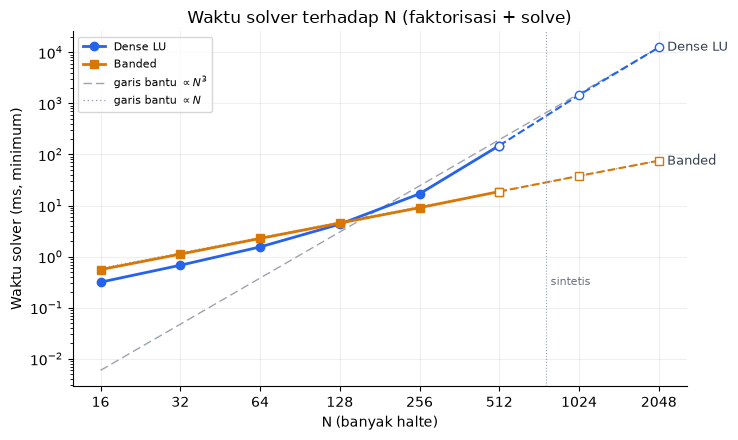

In [54]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_dua_solver(ax, 'solver_dense_s', 'solver_band_s', 1e3, 'Waktu solver (ms, minimum)')
akhir = df_bench_semua.iloc[-1]
garis_referensi(ax, akhir['N'], akhir['solver_dense_s'] * 1e3, 3, r'$\propto N^3$', (0, (6, 3)))
garis_referensi(ax, akhir['N'], akhir['solver_band_s'] * 1e3, 1, r'$\propto N$', (0, (1, 2)))
ax.set_title('Waktu solver terhadap N (faktorisasi + solve)')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(HASIL / 'waktu_vs_N.png', dpi=200)
plt.show()

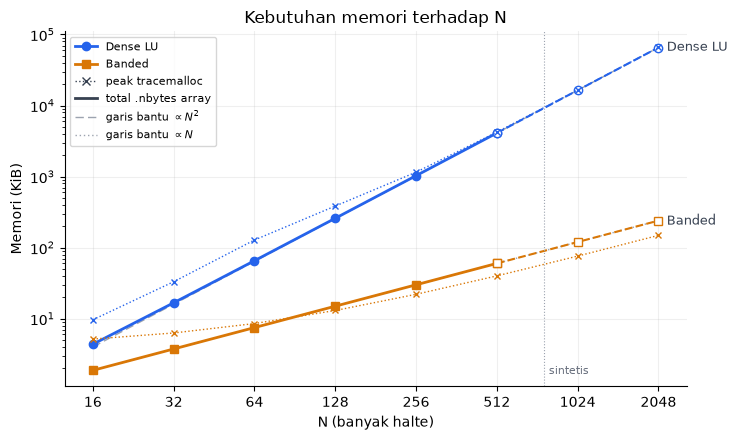

In [55]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_dua_solver(ax, 'nbytes_dense', 'nbytes_band', 1 / 1024, 'Memori (KiB)')
for kolom, warna in (('peak_dense_byte', WARNA_DENSE), ('peak_band_byte', WARNA_BAND)):
    ax.plot(df_bench_semua['N'], df_bench_semua[kolom] / 1024, color=warna, linewidth=1, linestyle=':',
            marker='x', markersize=5)
ax.plot([], [], color='#374151', linewidth=1, linestyle=':', marker='x', label='peak tracemalloc')
ax.plot([], [], color='#374151', linewidth=2, label='total .nbytes array')
akhir = df_bench_semua.iloc[-1]
garis_referensi(ax, akhir['N'], akhir['nbytes_dense'] / 1024, 2, r'$\propto N^2$', (0, (6, 3)))
garis_referensi(ax, akhir['N'], akhir['nbytes_band'] / 1024, 1, r'$\propto N$', (0, (1, 2)))
ax.set_title('Kebutuhan memori terhadap N')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(HASIL / 'memori_vs_N.png', dpi=200)
plt.show()

Untuk $N \le 128$ kedua solver setara; solver banded sedikit lebih lambat karena setiap langkahnya berupa loop
Python kecil, sedangkan solver dense memakai operasi vektor NumPy. Mulai $N = 256$ solver banded lebih cepat
(beberapa kali lipat pada $N = 512$ dan lebih dari 100× pada $N = 2048$ sintetis). Memori array dense sekitar 68× memori
banded pada $N = 512$. Pada $N = 512$, waktu membaca CSV sudah lebih besar dari waktu solver banded.

## vi. Analisis Kompleksitas

In [56]:
# Flop faktorisasi, suku utama saja, konvensi kelas (satu pasangan kali-kurang = 1 flop).
# Substitusi dihitung terpisah: dense ~ N^2 (N^2/2 maju + N^2/2 mundur), banded O(N).
def flop_dense(N: int) -> float:
    return N ** 3 / 3


# Banded dengan partial pivoting: N p (p+q) operasi dan (2p+q+1) N memori.
# (Rumus slide (p+q)^2/4 N adalah versi tanpa pivoting, tidak dihitung di sini.)
def flop_band(N: int, p: int, q: int) -> int:
    return N * p * (p + q)


p, q = 2, 1
KOLOM_FLOP_DENSE = 'flop faktorisasi dense (suku utama)'
KOLOM_FLOP_BAND = 'flop faktorisasi banded (suku utama)'
df_teori = pd.DataFrame({'N': df_bench_semua['N']})
df_teori[KOLOM_FLOP_DENSE] = [flop_dense(int(N)) for N in df_teori['N']]
df_teori[KOLOM_FLOP_BAND] = [flop_band(int(N), p, q) for N in df_teori['N']]
df_teori['rasio_flop'] = df_teori[KOLOM_FLOP_DENSE] / df_teori[KOLOM_FLOP_BAND]
df_teori['memori_teori_dense_byte'] = 8 * df_teori['N'] ** 2                   # array faktor LU
df_teori['memori_teori_band_byte'] = 8 * (2 * p + q + 1) * df_teori['N']       # array faktor AB
df_teori.to_csv(HASIL / 'flop_teori.csv', index=False)
df_teori

,N,flop faktorisasi dense (suku utama),flop faktorisasi banded (suku utama),rasio_flop,memori_teori_dense_byte,memori_teori_band_byte
0,16,1.365333e+03,96,14.222222,2048,768
1,32,1.092267e+04,192,56.888889,8192,1536
2,64,8.738133e+04,384,227.555556,32768,3072
3,128,6.990507e+05,768,910.222222,131072,6144
4,256,5.592405e+06,1536,3640.888889,524288,12288
5,512,4.473924e+07,3072,14563.555556,2097152,24576
6,1024,3.579139e+08,6144,58254.222222,8388608,49152
7,2048,2.863312e+09,12288,233016.888889,33554432,98304


In [57]:
def kemiringan_loglog(x, y) -> float:
    lx, ly = np.log(np.asarray(x, float)), np.log(np.asarray(y, float))
    return float(np.sum((lx - lx.mean()) * (ly - ly.mean())) / np.sum((lx - lx.mean()) ** 2))


rentang = {
    'data N=16..512': df_bench_semua['sumber'] == 'data',
    'data N=128..512': (df_bench_semua['sumber'] == 'data') & (df_bench_semua['N'] >= 128),
    'N=256..2048 (+sintetis)': df_bench_semua['N'] >= 256,
}
besaran = {
    'waktu dense (teori 3)': df_bench_semua['solver_dense_s'],
    'waktu band (teori 1)': df_bench_semua['solver_band_s'],
    'flop faktorisasi dense (teori 3)': df_teori[KOLOM_FLOP_DENSE],
    'flop faktorisasi banded (teori 1)': df_teori[KOLOM_FLOP_BAND],
    'nbytes dense (teori 2)': df_bench_semua['nbytes_dense'],
    'nbytes band (teori 1)': df_bench_semua['nbytes_band'],
    'peak dense (teori 2)': df_bench_semua['peak_dense_byte'],
    'peak band (teori 1)': df_bench_semua['peak_band_byte'],
}
df_kemiringan = pd.DataFrame({
    nama_r: {nama_b: kemiringan_loglog(df_bench_semua['N'][m], y[m]) for nama_b, y in besaran.items()}
    for nama_r, m in rentang.items()
}).round(2)
df_kemiringan.to_csv(HASIL / 'kemiringan_loglog.csv')
df_kemiringan

,data N=16..512,data N=128..512,N=256..2048 (+sintetis)
waktu dense (teori 3),1.71,2.56,3.18
waktu band (teori 1),1.01,1.02,1.02
flop faktorisasi dense (teori 3),3.00,3.00,3.00
flop faktorisasi banded (teori 1),1.00,1.00,1.00
nbytes dense (teori 2),1.98,1.99,2.00
nbytes band (teori 1),1.00,1.00,1.00
peak dense (teori 2),1.74,1.73,1.95
peak band (teori 1),0.59,0.81,0.92


In [58]:
# Rasio waktu saat N digandakan (teori: dense 8x, band 2x)
df_rasio = pd.DataFrame({
    'N': df_bench_semua['N'].iloc[1:].values,
    'rasio_waktu_dense': (df_bench_semua['solver_dense_s'].values[1:] / df_bench_semua['solver_dense_s'].values[:-1]),
    'rasio_waktu_band': (df_bench_semua['solver_band_s'].values[1:] / df_bench_semua['solver_band_s'].values[:-1]),
}).round(2)
df_rasio

,N,rasio_waktu_dense,rasio_waktu_band
0,32,2.15,2.01
1,64,2.28,2.03
2,128,2.79,2.00
3,256,3.94,2.00
4,512,8.80,2.07
5,1024,9.75,2.02
6,2048,8.53,1.99


Hitungan flop dan `.nbytes` mengikuti teori tepat (kemiringan 3 dan 2 untuk dense, 1 untuk banded). Waktu solver
banded linear di semua rentang (kemiringan sekitar 1). Waktu solver dense baru mendekati $N^3$ untuk $N \ge 256$;
pada $N$ kecil biaya tetap per langkah (overhead Python/NumPy) mendominasi sehingga kemiringannya jauh di bawah 3.
Peak `tracemalloc` banded pada $N$ kecil didominasi alokasi kecil berukuran tetap, sehingga kemiringannya < 1.